# 无分类器扩散引导（Classifier-free Diffusion Guidance）

正如你在[之前的示例](./06-classifier-guidance-cn.ipynb)中所看到的，**分类器引导扩散（classifier-guided diffusion）** 需要一个额外的分类器。而构建这样的分类器是非常困难的，因为它需要在加入高斯噪声后的样本上进行训练。  

此外，当条件信息是诸如通用文本序列(文本提示词)这类复杂条件时，使用分类器进行预测也会变得更加困难。

**无分类器引导（Classifier-free guidance）** 的提出，旨在构建一种扩散模型：  
它可以像分类器引导那样生成“低温度(low temperature)”的样本，但**不需要额外的分类器**。

其主要特点包括：

- 与分类器引导类似，你可以在**生成质量(fidelity)与多样性(diversity)之间进行权衡**，这一点类似于常规大语言模型(LLM)中的“温度(temperature)”参数;
- 无分类器引导**不需要一个在加噪图像上训练的额外分类器模型**;
- 因为它不依赖分类器，无分类器引导模型的架构可以**稳定地扩展到以文本序列(或其他模态)作为条件的生成模型**。(见下方说明)


## 架构与方法

现在我们从**分类器引导扩散（classifier-guided diffusion）**中的如下公式开始(参见 [分类器引导教程](./06-classifier-guidance-cn.ipynb) 中的公式 (6), 分类器引导应用于条件扩散模型场景)，并尝试将该公式改写为**不再使用分类器** $p(y \mid \mathbf{x}_t)$ 的形式。

$
\tilde{\epsilon}_{\theta}(\mathbf{x}_t, y)
=
\epsilon_{\theta}(\mathbf{x}_t, y)
-
s \, \sigma_t \, \nabla_{\mathbf{x}_t} \log p(y \mid \mathbf{x}_t)
\qquad (1)
$

根据贝叶斯法则，分类器 $p(y \mid \mathbf{x}_t)$ 具有如下性质：

$
p(y \mid \mathbf{x}_t) \propto \frac{p(\mathbf{x}_t \mid y)}{p(\mathbf{x}_t)}
$

因此，有：

$
\nabla_{\mathbf{x}_t} \log p(y \mid \mathbf{x}_t)
=
\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t \mid y)
-
\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)
\qquad (2)
$

将公式 (2) 代入公式 (1)，可以得到：

$
\tilde{\epsilon}_{\theta}(\mathbf{x}_t, y)
=
\epsilon_{\theta}(\mathbf{x}_t, y)
-
s \, \sigma_t
\left(
\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t \mid y)
-
\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)
\right)
$

如同我们在分类器引导扩散中看到的那样，有：

$
\epsilon_{\theta}(\mathbf{x}_t)
=
-\sigma_t \nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)
$

因此，上式可以改写为：

$
\tilde{\epsilon}_{\theta}(\mathbf{x}_t, y)
=
(1 + s)\,\epsilon_{\theta}(\mathbf{x}_t, y)
-
s\,\epsilon_{\theta}(\mathbf{x}_t)
\qquad (3)
$

> **说明**：  
> 如上所示，当 $s = 0$ 时，该模型退化为[传统条件扩散模型](./05-class-conditional-cn.ipynb)。  
> 若令 $s' = -s$，则有$\tilde{\epsilon}_{\theta}(\mathbf{x}_t, y) = (1 - s^{\prime}) \epsilon_{\theta}(\mathbf{x}_t, y) + s^{\prime} \epsilon_{\theta}(\mathbf{x}_t)$ 此时，$s'$ 的作用类似于一个归一化因子，但它始终是负值。

可以看到，公式 (3) **完全不再依赖分类器**。  
与分类器引导中使用额外分类器不同，该方法通过**联合训练两个 score 函数**来实现引导效果：一个条件扩散模型 $\epsilon_{\theta}(\mathbf{x}_t, y)$ 和一个无条件扩散模型 $\epsilon_{\theta}(\mathbf{x}_t)$

> **说明**：  
> 虽然理论上可以分别训练 $\epsilon_{\theta}(\mathbf{x}_t, y)$ 和 $\epsilon_{\theta}(\mathbf{x}_t)$，但这样会显著增加训练难度。因此，在原论文中，这两个模型是**联合训练**的(本教程中同样采用联合训练方式)。更多细节可参考原始论文：[Ho & Salimans, 2022](https://arxiv.org/pdf/2207.12598)


## 说明：结合文本提示的无分类器引导（文本到图像）

在本示例中，为了便于学习，我们将使用**类别标签（class label）**来构建一个简单的**无分类器引导扩散模型（classifier-free guided model）**。  
不过，该架构同样可以扩展为**以通用文本提示（text prompt）为条件的引导模型**，其方式是引入文本编码器，例如 [Transformer 编码器](https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb) 等。

例如，在论文 [[Nichol et al., 2022](https://arxiv.org/pdf/2112.10741)]（即 **GLIDE** 的论文）中，作者比较了两种文本到图像的引导扩散方法：

- **分类器引导扩散**（即在 [分类器引导教程](./06-classifier-guidance-cn.ipynb) 中讨论的 CLIP 引导）
- **无分类器引导扩散**（使用基于 Transformer 的文本编码器）

实验结果表明，在多个方面上，**无分类器引导方法表现出更优的效果**。

目前，无分类器引导架构已经被广泛应用于许多著名的扩散模型中，例如 **GLIDE、Imagen 以及 Stable Diffusion**。  
其中，**GLIDE 与 Imagen 的一个核心差异在于文本编码器的选择**：Imagen 使用了一个**冻结的（预训练的）大型语言模型**作为文本编码器。

**Stable Diffusion**（截至版本 2）同样采用了 CLIP 中已有的、冻结的（预训练）文本编码器。  
而在 **Stable Diffusion 第 3 版及之后的版本**中，模型将 **CLIP 编码器** 与 **面向文本理解的编码器（T5）** 进行联合使用，以提升对文本细节的理解能力，例如对高度细节化描述或较长文本的理解能力。（亦可参考 NVIDIA 的论文 [[Balaji et al., 2023](https://arxiv.org/pdf/2211.01324)]。）


## 构建和训练模型

现在就让我们来先一下具体的代码实现。

在我们开始之前，我们需要安装所需的包。

In [5]:
!pip install torch torchvision numpy matplotlib tqdm

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


### 1. 加载数据

我们加载 CIFAR-10 数据集及其数据加载器(dataloader)，每个batch具有形状 ```[batch_size, 3, 32 32]```。

In [7]:
import torch
from torchvision import datasets, transforms

batch_size = 128

dataset = datasets.CIFAR100(
    "./data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]))
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


现在展示 100 个例子。

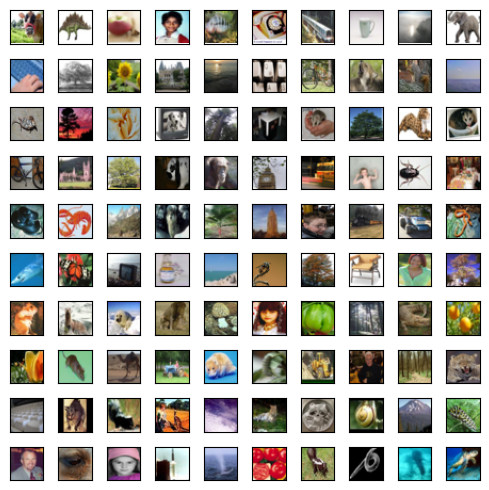

In [9]:
import numpy as np
import matplotlib.pyplot as plt

"""
for _, (data, _) in enumerate(loader):
    images = data[:3]
    break
for i in images:
    channel_last = np.transpose(i.numpy(), (1, 2, 0)) # (C, H, W) --> (H, W, C)
    plt.figure(figsize = (0.4,0.4))
    plt.imshow(channel_last)
    plt.show()
"""
num_row = 10
num_col = 10
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
tmp_loader = torch.utils.data.DataLoader(dataset, batch_size=num_row*num_col, shuffle=False)
for data, label in tmp_loader:
    for i in range(num_row*num_col):
        image = data[i].numpy()
        channel_last = np.transpose(image, (1, 2, 0)) # (C, H, W) --> (H, W, C)
        row = i//num_col
        col = i%num_col
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(channel_last)
    break
plt.tight_layout()
plt.show()
del tmp_loader

如下所示，在这个数据集中存在100个类别：

In [11]:
num_classes = 100
classes = [
    "apple",
    "aquarium_fish",
    "baby",
    "bear",
    "beaver",
    "bed",
    "bee",
    "beetle",
    "bicycle",
    "bottle",
    "bowl",
    "boy",
    "bridge",
    "bus",
    "butterfly",
    "camel",
    "can",
    "castle",
    "caterpillar",
    "cattle",
    "chair",
    "chimpanzee",
    "clock",
    "cloud",
    "cockroach",
    "couch",
    "crab",
    "crocodile",
    "cup",
    "dinosaur",
    "dolphin",
    "elephant",
    "flatfish",
    "forest",
    "fox",
    "girl",
    "hamster",
    "house",
    "kangaroo",
    "keyboard",
    "lamp",
    "lawn_mower",
    "leopard",
    "lion",
    "lizard",
    "lobster",
    "man",
    "maple_tree",
    "motorcycle",
    "mountain",
    "mouse",
    "mushroom",
    "oak_tree",
    "orange",
    "orchid",
    "otter",
    "palm_tree",
    "pear",
    "pickup_truck",
    "pine_tree",
    "plain",
    "plate",
    "poppy",
    "porcupine",
    "possum",
    "rabbit",
    "raccoon",
    "ray",
    "road",
    "rocket",
    "rose",
    "sea",
    "seal",
    "shark",
    "shrew",
    "skunk",
    "skyscraper",
    "snail",
    "snake",
    "spider",
    "squirrel",
    "streetcar",
    "sunflower",
    "sweet_pepper",
    "table",
    "tank",
    "telephone",
    "television",
    "tiger",
    "tractor",
    "train",
    "trout",
    "tulip",
    "turtle",
    "wardrobe",
    "whale",
    "willow_tree",
    "wolf",
    "woman",
    "worm"
]

### 2. 构建类别条件 U-Net $\epsilon_{\theta}(\mathbf{x}, y)$

在原论文 [[Ho & Salimans, 2022](https://arxiv.org/pdf/2207.12598)] 中，模型架构来源于 [这里](https://arxiv.org/pdf/2107.00630)（这是概率扩散模型的一个改进版本）。  
但是，在本笔记本中，我们将把**无分类器引导（classifier-free guidance）**应用到[条件扩散教程](./05-class-conditional-cn.ipynb) 中的模型之上。

下面的代码(模型实现)与 [条件扩散教程](./05-class-conditional-cn.ipynb) 基本相同，但 `U-Net` 剥离了**类别嵌入层**(`class embedding layer`)。


In [13]:
import torch
import torch.nn as nn
from torch.nn import functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
#
# Define blocks
#

class PositionalEncoding(nn.Module):
    def __init__(
        self,
        base_dim, # 128
        hidden_dim, # 256
        output_dim, # 512
    ):
        super().__init__()

        # In this example, we assume that the number of embedding dimension is always even.
        # (If not, please pad the result.)
        assert(base_dim % 2 == 0)
        self.timestep_dim = base_dim

        self.hidden1 = nn.Linear(
            base_dim,
            hidden_dim)
        self.hidden2 = nn.Linear(
            hidden_dim,
            output_dim)

    def forward(self, picked_up_timesteps):
        # Generate 1 / 10000^{2i / d_e}
        # shape : (timestep_dim / 2, )
        interval = 1.0 / (10000**(torch.arange(0, self.timestep_dim, 2.0).to(device) / self.timestep_dim))
        # Generate t / 10000^{2i / d_e}
        # shape : (batch_size, timestep_dim / 2)
        position = picked_up_timesteps.type(torch.get_default_dtype())
        radian = position[:, None] * interval[None, :]
        # Get sin(t / 10000^{2i / d_e}) and unsqueeze
        # shape : (batch_size, timestep_dim / 2, 1)
        sin = torch.sin(radian).unsqueeze(dim=-1)
        # Get cos(t / 10000^{2i / d_e}) and unsqueeze
        # shape : (batch_size, timestep_dim / 2, 1)
        cos = torch.cos(radian).unsqueeze(dim=-1)
        # Get sinusoidal positional encoding
        # shape : (batch_size, timestep_dim)
        pe_tmp = torch.concat((sin, cos), dim=-1)   # shape : (num_timestep, timestep_dim / 2, 2)
        d = pe_tmp.size()[1]
        pe = pe_tmp.view(-1, d * 2)                 # shape : (num_timestep, timestep_dim)
        # Apply feedforward
        # shape : (batch_size, timestep_dim * 4)
        out = self.hidden1(pe)
        out = F.silu(out)
        out = self.hidden2(out)

        return out

class ResnetBlock(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        embedding_dim, # 512
    ):
        super().__init__()

        # for normalization
        self.norm1 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=in_channel,
            eps=1e-06,
        )
        self.norm2 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=out_channel,
            eps=1e-06,
        )

        # for applying conv
        self.conv1 = nn.Conv2d(
            in_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.conv2 = nn.Conv2d(
            out_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

        # for time and class projection
        self.linear_time = nn.Linear(embedding_dim, out_channel)
        self.linear_class = nn.Linear(embedding_dim, out_channel)

        # for residual block
        if in_channel != out_channel:
            self.linear_src = nn.Linear(in_channel, out_channel)
        else:
            self.linear_src = None

    def forward(self, x, t_emb, y_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            timestep embeddings
        y_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            class embeddings
        """

        # apply conv
        out = self.norm1(x)
        out = F.silu(out)
        out = self.conv1(out)

        # apply AdaGN (adaptive group normalization)
        t_prj = F.silu(t_emb)
        t_prj = self.linear_time(t_prj)
        t_prj = t_prj[:, :, None, None]

        y_prj = F.silu(y_emb)
        y_prj = self.linear_class(y_prj)
        y_prj = y_prj[:, :, None, None]

        out = out * t_prj + y_prj

        # apply dropout + conv
        out = self.norm2(out)
        out = F.silu(out)
        out = F.dropout(out, p=0.1, training=self.training)
        out = self.conv2(out)

        # apply residual
        if self.linear_src is not None:
            x_trans = x.permute(0, 2, 3, 1)       # (N,C,H,W) --> (N,H,W,C)
            x_trans = self.linear_src(x_trans)
            x_trans = x_trans.permute(0, 3, 1, 2) # (N,H,W,C) --> (N,C,H,W)
            out = out + x_trans
        else:
            out = out + x

        return out

class AttentionBlock(nn.Module):
    def __init__(
        self,
        channel,
        num_norm_groups, # 32
    ):
        super().__init__()

        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=channel,
            eps=1e-06,
        )

        self.q_layer = nn.Linear(channel, channel)
        self.k_layer = nn.Linear(channel, channel)
        self.v_layer = nn.Linear(channel, channel)

        self.output_linear = nn.Linear(channel, channel, bias=False)

    def forward(self, x):
        channel = x.size(dim=1)
        height = x.size(dim=2)
        width = x.size(dim=3)

        out = self.norm(x)

        # reshape : (N,C,H,W) --> (N,H*W,C)
        out = out.permute(0, 2, 3, 1)
        out = out.view(-1, height*width, channel)

        # generate query/key/value
        q = self.q_layer(out)
        k = self.k_layer(out)
        v = self.v_layer(out)

        # compute Q K^T
        score = torch.einsum("bic,bjc->bij", q, k)

        # scale the result by 1/sqrt(channel)
        score = score / channel**0.5

        # apply softtmax
        score = F.softmax(score, dim=-1)

        # apply dot product with values
        out = torch.einsum("bij,bjc->bic", score, v)

        # apply final linear
        out = self.output_linear(out)

        # reshape : (N,H*W,C) --> (N,C,H,W)
        out = out.view(-1, height, width, channel)
        out = out.permute(0, 3, 1, 2)

        # apply residual
        out = out + x

        return out

class ResnetAndAttention(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        embedding_dim, # 512
    ):
        super().__init__()

        self.resnet = ResnetBlock(
            in_channel,
            out_channel,
            num_norm_groups,
            embedding_dim,
        )
        self.attention = AttentionBlock(
            out_channel,
            num_norm_groups,
        )

    def forward(self, x, t_emb, y_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            timestep embeddings
        y_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            class embeddings
        """
        out = self.resnet(x, t_emb, y_emb)
        out = self.attention(out)
        return out

class DownSample(nn.Module):
    def __init__(
        self,
        channel,
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            channel,
            channel,
            kernel_size=3,
            stride=2,
            padding=1,
        )

    def forward(self, x):
        return self.conv(x)

class UpSample(nn.Module):
    def __init__(
        self,
        channel,
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            channel,
            channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

    def forward(self, x):
        out = F.interpolate(x, scale_factor=2, mode="nearest")
        out = self.conv(out)
        return out

In [15]:
#
# Define U-Net
#

class UNet(nn.Module):
    def __init__(
        self,
        source_channel, # 3
        unet_base_channel, # 128
        num_norm_groups, # 32
    ):
        super().__init__()

        self.pos_enc = PositionalEncoding(
            base_dim=unet_base_channel,
            hidden_dim=unet_base_channel*2,
            output_dim=unet_base_channel*4,
        )

        self.down_conv = nn.Conv2d(
            source_channel,
            unet_base_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.top_to_down = nn.ModuleList([
            # 1st layer
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel,
            ),
            # 2nd layer
            ResnetAndAttention(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel*2,
            ),
            # 3rd layer
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel*2,
            ),
            # 4th layer
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
        ])
        self.middle = nn.ModuleList([
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            AttentionBlock(
                channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
        ])
        self.bottom_to_up = nn.ModuleList([
            # 1st layer
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 2nd layer
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 3rd layer
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*3,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 4th layer
            ResnetBlock(
                in_channel=unet_base_channel*3,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                embedding_dim=unet_base_channel*4,
            ),
        ])
        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=unet_base_channel,
            eps=1e-06,
        )
        self.up_conv = nn.Conv2d(
            unet_base_channel,
            source_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

    def forward(self, x, t, y_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            Gaussian-noised images
        t : torch.tensor((batch_size), dtype=int)
            timestep
        y_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            class embeddings
        """

        buffer = []

        # generate time embedding
        time_embs = self.pos_enc(t)

        #
        # Top-to-down
        #

        # apply down-convolution
        out = self.down_conv(x)
        buffer.append(out)
        # apply top-to-down
        for block in self.top_to_down:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs, y_emb)
            elif isinstance(block, ResnetAndAttention):
                out = block(out, time_embs, y_emb)
            elif isinstance(block, DownSample):
                out = block(out)
            else:
                raise Exception("Unknown block")
            buffer.append(out)

        #
        # Middle
        #
        for block in self.middle:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs, y_emb)
            elif isinstance(block, AttentionBlock):
                out = block(out)
            else:
                raise Exception("Unknown block")

        #
        # Bottom-to-up
        #

        # apply bottom-to-up
        for block in self.bottom_to_up:
            if isinstance(block, ResnetBlock):
                buf = buffer.pop()
                out = torch.cat((out, buf), dim=1)
                out = block(out, time_embs, y_emb)
            elif isinstance(block, ResnetAndAttention):
                buf = buffer.pop()
                out = torch.cat((out, buf), dim=1)
                out = block(out, time_embs, y_emb)
            elif isinstance(block, UpSample):
                out = block(out)
            else:
                raise Exception("Unknown block")
        # apply up-convolution
        out = self.norm(out)
        out = F.silu(out)
        out = self.up_conv(out)

        assert not buffer

        return out

In [16]:
#
# Generate model (U-Net)
#
unet_base_channel = 128
emb = nn.Embedding(num_classes, unet_base_channel*4).to(device)
unet = UNet(
    source_channel=3,
    unet_base_channel=unet_base_channel,
    num_norm_groups=32,
).to(device)

### 3. 联合训练 $\epsilon_{\theta}(\mathbf{x}, y)$ 和 $\epsilon_{\theta}(\mathbf{x}, \varnothing)$

现在我们开始训练 $\epsilon_{\theta}$。

如前所述，我们需要两个 score 函数：一个是**条件 score** $\epsilon_{\theta}(\mathbf{x}, y)$，另一个是**无条件 score** $\epsilon_{\theta}(\mathbf{x})$，但这里我们使用**单个神经网络联合训练这两个 score 函数**。

在初始设置中，我们首先设定**无条件训练的概率** $p_{\verb|uncond|}$（这里设置为 $p_{\verb|uncond|} = 0.2$）。  
在训练过程中，有 $p_{\verb|uncond|}$ 的概率在训练时将条件 $y$ 设置成 $\varnothing$。

其他步骤与 [条件扩散教程](./05-class-conditional-cn.ipynb) 中讨论的常规条件扩散训练过程相同。

> **说明**：  
> 在示例中将训练停止在 200 个 epoch，但为了获得更高质量的样本，请运行更多的 epoch。  
> 使用单个 GPU 完整训练需要整整一天时间。


In [18]:
import os
import random

p_uncond = 0.2

# initialize optimizer
opt = torch.optim.Adam(list(emb.parameters()) + list(unet.parameters()), lr=2e-4, eps=1e-08)
scheduler = torch.optim.lr_scheduler.LinearLR(
    opt,
    start_factor=1.0/5000,
    end_factor=1.0,
    total_iters=5000)

# 1. Initialize T and alpha
#   (See above note for precision.)
T = 1000
alphas = torch.linspace(start=0.9999, end=0.98, steps=T, dtype=torch.float64).to(device)
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_alpha_bars_t = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars_t = torch.sqrt(1.0 - alpha_bars)

# remove log file if exists
log_file = "train_loss.log"
if os.path.exists(log_file):
    os.remove(log_file)

# loop
num_epochs = 200
for epoch_idx in range(num_epochs):
    epoch_loss = []
    for batch_idx, (data, y) in enumerate(loader):
        unet.train()
        opt.zero_grad()

        # Pick up x_0 (shape: [64, 3, 32, 32])
        x_0 = data.to(device)
        y_ = y.to(device)

        # Pick up random timestep, t .
        #    Instead of picking up t=1,2, ... ,T ,
        #    here we pick up t=0,1, ... ,T-1 .
        #   (i.e, t == 0 means diffused for 1 step)
        b = x_0.size(dim=0)
        t = torch.randint(T, (b,)).to(device)

        # Generate the seed of noise, epsilon .
        #    We just pick up from 1D standard normal distribution with the same shape,
        #    because off-diagonal elements in covariance is all zero.
        eps = torch.randn_like(x_0).to(device)

        # Compute x_t = sqrt(alpha_bar_t) x_0 + sqrt(1-alpha_bar_t) epsilon
        #    (t == 0 means diffused for 1 step)
        x_t = sqrt_alpha_bars_t[t][:,None,None,None].float() * x_0 + sqrt_one_minus_alpha_bars_t[t][:,None,None,None].float() * eps

        # Get class embedding
        y_emb = emb(y_)

        # Set empty in class embedding with probability p_uncond (See above)
        rnd = torch.rand(b).to(device)
        mul = torch.where(rnd < p_uncond, 0.0, 1.0)
        y_emb = y_emb * mul[:,None]

        # Get loss and apply gradient (update)
        model_out = unet(x_t, t, y_emb)
        loss = F.mse_loss(model_out, eps, reduction="mean")
        loss.backward()
        opt.step()
        scheduler.step()

        # log
        epoch_loss.append(loss.item())
        print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, loss), end="\r")

    # finalize epoch (save log and checkpoint)
    epoch_average_loss = sum(epoch_loss)/len(epoch_loss)
    print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, epoch_average_loss))
    with open(log_file, "a") as f:
        for l in epoch_loss:
            f.write("%s\n" %l)
    torch.save(unet.state_dict(), f"guided_unet_{epoch_idx}.pt")
    torch.save(emb.state_dict(), f"guided_embedding_{epoch_idx}.pt")

print("Done")

epoch1 (iter391) - loss 0.6938
epoch2 (iter391) - loss 0.0830
epoch3 (iter391) - loss 0.0440
epoch4 (iter391) - loss 0.0324
epoch5 (iter391) - loss 0.0280
epoch6 (iter391) - loss 0.0251
epoch7 (iter391) - loss 0.0242
epoch8 (iter391) - loss 0.0224
epoch9 (iter391) - loss 0.0223
epoch10 (iter391) - loss 0.0215
epoch11 (iter391) - loss 0.0212
epoch12 (iter391) - loss 0.0206
epoch13 (iter391) - loss 0.0199
epoch14 (iter391) - loss 0.0199
epoch15 (iter391) - loss 0.0198
epoch16 (iter391) - loss 0.0192
epoch17 (iter391) - loss 0.0194
epoch18 (iter391) - loss 0.0189
epoch19 (iter391) - loss 0.0188
epoch20 (iter391) - loss 0.0190
epoch21 (iter391) - loss 0.0186
epoch22 (iter391) - loss 0.0181
epoch23 (iter391) - loss 0.0183
epoch24 (iter391) - loss 0.0184
epoch25 (iter391) - loss 0.0181
epoch27 (iter391) - loss 0.0185
epoch28 (iter391) - loss 0.0179
epoch29 (iter391) - loss 0.0181
epoch30 (iter391) - loss 0.0183
epoch31 (iter391) - loss 0.0178
epoch32 (iter391) - loss 0.0180
epoch33 (iter391)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch40 (iter391) - loss 0.0181
epoch41 (iter391) - loss 0.0174
epoch42 (iter391) - loss 0.0175
epoch43 (iter391) - loss 0.0175
epoch44 (iter391) - loss 0.0176
epoch45 (iter391) - loss 0.0178
epoch46 (iter391) - loss 0.0179
epoch47 (iter391) - loss 0.0175
epoch48 (iter391) - loss 0.0178
epoch49 (iter391) - loss 0.0178
epoch50 (iter391) - loss 0.0176
epoch51 (iter391) - loss 0.0177
epoch52 (iter391) - loss 0.0174
epoch53 (iter391) - loss 0.0176
epoch54 (iter391) - loss 0.0174
epoch55 (iter391) - loss 0.0174
epoch56 (iter391) - loss 0.0175
epoch57 (iter391) - loss 0.0176
epoch58 (iter391) - loss 0.0178
epoch59 (iter391) - loss 0.0174
epoch60 (iter391) - loss 0.0175
epoch61 (iter391) - loss 0.0178
epoch62 (iter391) - loss 0.0171
epoch63 (iter391) - loss 0.0173
epoch64 (iter391) - loss 0.0175
epoch65 (iter391) - loss 0.0176
epoch66 (iter391) - loss 0.0174
epoch67 (iter391) - loss 0.0171
epoch68 (iter391) - loss 0.0169
epoch69 (iter391) - loss 0.0172
epoch70 (iter391) - loss 0.0177
epoch71 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## 无分类器引导的图像生成

如上所示，我们在采样时使用以下噪声预测更新公式：

$
\tilde{\epsilon}_{\theta}(\mathbf{x}_t, y) = (1 + s) \, \epsilon_{\theta}(\mathbf{x}_t, y) - s \, \epsilon_{\theta}(\mathbf{x}_t, \varnothing)
$

从下面的生成结果可以看出，当**减小引导比例 $s$** 时，样本的**多样性（diversity）增加**；而**较大的 $s$** 可以提升采样的**保真度（fidelity）**。


In [20]:
import tqdm

def run_inference(unet, emb, class_name, class_list, s, num_row=10, num_col=10):
    unet.eval()

    ##########
    # generate sigma_t
    ##########
    alpha_bars_prev = torch.cat((torch.ones(1).to(device), alpha_bars[:-1]))
    sigma_t_squared = (1.0 - alphas) * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)
    sigma_t = torch.sqrt(sigma_t_squared)

    ##########
    # make white noise
    ##########
    x = torch.randn(num_row*num_col, 3, 32, 32).to(device)

    ##########
    # generate images
    ##########
    with torch.no_grad():
        # generate class embedding
        # (the first half is for epsilon(x, y), the second half is for epsilon(x, empty))
        class_id_list = [i for i,v in enumerate(class_list) if v==class_name]
        if len(class_id_list) == 0:
            raise Exception("class name doesn't exist")
        y = class_id_list[0]
        y_batch = (torch.tensor(y).to(device)).repeat(num_row*num_col)
        y_batch = torch.cat((y_batch, y_batch), dim=0)
        y_emb_batch = emb(y_batch)
        mask = torch.cat((
            torch.ones(num_row*num_col).to(device),
            torch.zeros(num_row*num_col).to(device)))
        y_emb_batch = y_emb_batch * mask[:,None]
        # loop T-1, T-2, ... ,0
        for t in tqdm.tqdm(reversed(range(T)), total=T):
            # generate t
            # (the first half is for epsilon(x, y), the second half is for epsilon(x, empty))
            t_batch = (torch.tensor(t).to(device)).repeat(num_row*num_col)
            t_batch = torch.cat((t_batch, t_batch), dim=0)
            # compute epsilon
            # (the first half is for epsilon(x, y), the second half is for epsilon(x, empty))
            x_batch = torch.cat((x, x), dim=0)
            eps_batch = unet(x_batch, t_batch, y_emb_batch)
            eps_cond, eps_uncond = torch.split(eps_batch, len(eps_batch)//2, dim=0)
            eps = (1.0 + s) * eps_cond - s * eps_uncond
            # update x
            if t > 0:
                z = torch.randn(num_row*num_col, 3, 32, 32).to(device)
            else:
                z = torch.zeros(num_row*num_col, 3, 32, 32).to(device)
            x = (1.0 / torch.sqrt(alphas[t])).float() * (x - ((1.0 - alphas[t]) / torch.sqrt(1.0 - alpha_bars[t])).float() * eps) + \
                sigma_t[t].float() * z

    ##########
    # output
    ##########

    # reshape to channels-last : (N,C,H,W) --> (N,H,W,C)    
    x = x.permute(0, 2, 3, 1)
    # clip
    x = torch.clamp(x, min=0.0, max=1.0)
    # draw
    fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
    for i in range(num_row*num_col):
        image = x[i].cpu().numpy()
        row = i//num_col
        col = i%num_col
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(image)

#### $s=3.0$

100%|██████████| 1000/1000 [02:02<00:00,  8.18it/s]


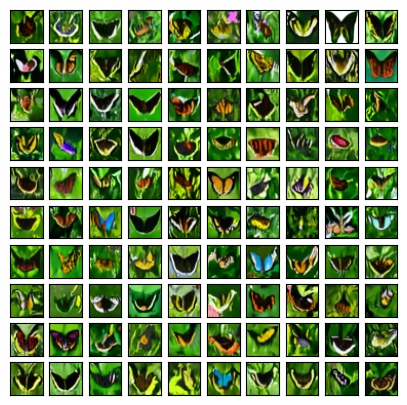

In [22]:
run_inference(
    unet,
    emb,
    class_name="butterfly",
    class_list=classes,
    s=3.0,
)

#### $s=0.1$

100%|██████████| 1000/1000 [02:02<00:00,  8.18it/s]


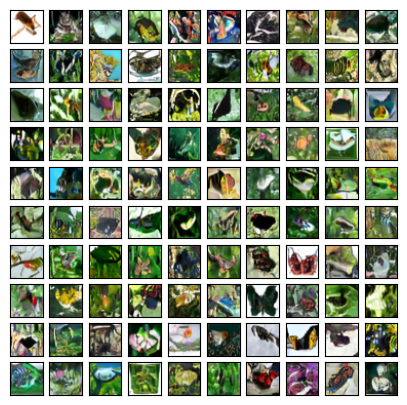

In [24]:
run_inference(
    unet,
    emb,
    class_name="butterfly",
    class_list=classes,
    s=0.1,
)